In [1]:
%load_ext watermark


In [2]:
import os
import subprocess

os.environ["POLARS_FORCE_NEW_STREAMING"] = "1"

from IPython.display import display, HTML
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
from teeplot import teeplot as tp
from tqdm import tqdm

from pylib._calc_compsummary_stats import calc_compsummary_stats
from pylib._seed_global_rngs import seed_global_rngs


Covasim 3.1.6 (2024-01-28) — © 2020-2024 by IDM


In [3]:
%watermark -diwmuv -iv


Last updated: 2025-12-14T00:07:38.290051+00:00

Python implementation: CPython
Python version       : 3.10.12
IPython version      : 7.31.1

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.8.0-1041-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit

polars : 1.29.0
seaborn: 0.13.2
numpy  : 2.1.2
teeplot: 1.4.2
pandas : 2.2.3

Watermark: 2.4.3



In [4]:
teeplot_subdir = "2025-05-19-compscreen-multistrain-summary"
teeplot_subdir


'2025-05-19-compscreen-multistrain-summary'

In [5]:
seed_global_rngs(1)


## Get Data


In [6]:
data_sources = {
    # "uk": "https://osf.io/mkjy5/download",
    "multistrain": "https://osf.io/ywmpt/download",
    # "vanilla": "https://osf.io/r8skg/download",
    # "vanilla-big": "https://osf.io/j4795/download",
    # "vanilla-big-1.3x": "https://osf.io/cnp5z/download",
}
tmp_path = f"/tmp/{teeplot_subdir}.pqt"


In [7]:
results = []

for source_name, url in data_sources.items():
    print(f"Downloading {source_name} data from {url}")

    subprocess.run(
        [
            "wget",
            "--tries=5",
            "--show-progress",
            "--progress=bar:force",
            "-O",
            str(tmp_path),
            url,
        ],
        check=True,
    )

    df = pl.scan_parquet(
        tmp_path,
        low_memory=True,
        retries=5,
    )

    unique_groups = (
        df.unique(
            [
                "trt_name",
                "trt_n_downsample",
                "trt_hsurf_bits",
                "replicate_uuid",
            ]
        )
        .select(
            pl.col("trt_name"),
            pl.col("trt_n_downsample"),
            pl.col("trt_hsurf_bits"),
            pl.col("replicate_uuid"),
        )
        .drop_nans()
        .drop_nulls()
        .collect(engine="streaming")
    )

    for (trt_name, trt_n_downsample, trt_hsurf_bits, replicate_uuid) in tqdm(
        [*unique_groups.iter_rows()],
    ):
        group = df.filter(
            (pl.col("trt_name") == trt_name)
            & (pl.col("trt_n_downsample") == trt_n_downsample)
            & (pl.col("trt_hsurf_bits") == trt_hsurf_bits)
            & (pl.col("replicate_uuid") == replicate_uuid)
        ).collect(engine="streaming")

        for y in (
            "defmut_norm_all-num_leaves",
            # "defmut_norm_ot_bin:week-num_leaves",
            # "defmut_norm_ot_bin:fortnight-num_leaves",
            "defmut_norm_ot_bin:month-num_leaves",
            # "defmut_norm_ot_bin:quarter-num_leaves",
            # "defmut_norm_ot_bin:year-num_leaves",
            "defmut_norm_match:variant_flavor-num_leaves",
            "defmut_norm_ot_bin:month&match:variant_flavor-num_leaves",
            "defmut_norm_all-clade_duration",
            # "defmut_norm_ot_bin:week-clade_duration",
            # "defmut_norm_ot_bin:fortnight-clade_duration",
            "defmut_norm_ot_bin:month-clade_duration",
            # "defmut_norm_ot_bin:quarter-clade_duration",
            # "defmut_norm_ot_bin:year-clade_duration",
            "defmut_norm_match:variant_flavor-clade_duration",
            "defmut_norm_ot_bin:month&match:variant_flavor-clade_duration",
        ):
            res = calc_compsummary_stats(
                group.to_pandas(),
                x="is_focal_defmut",
                y=y,
            )
            results.extend(
                {
                    "source_name": source_name,
                    "trt_name": trt_name,
                    "trt_n_downsample": trt_n_downsample,
                    "trt_hsurf_bits": trt_hsurf_bits,
                    "replicate_uuid": replicate_uuid,
                    "y": y,
                    **record,
                }
                for record in res
            )


--2025-12-14 00:07:38--  https://osf.io/ywmpt/download
Resolving osf.io (osf.io)... 35.190.84.173
Connecting to osf.io (osf.io)|35.190.84.173|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://osf.io/download/ywmpt [following]
--2025-12-14 00:07:38--  https://osf.io/download/ywmpt
Reusing existing connection to osf.io:443.
HTTP request sent, awaiting response... 308 Permanent Redirect
Location: https://osf.io/download/ywmpt/ [following]
--2025-12-14 00:07:38--  https://osf.io/download/ywmpt/
Reusing existing connection to osf.io:443.
HTTP request sent, awaiting response... 302 Found
Location: https://files.osf.io/v1/resources/37fv8/providers/osfstorage/682cae3abb3f815770b06cc8 [following]
--2025-12-14 00:07:38--  https://files.osf.io/v1/resources/37fv8/providers/osfstorage/682cae3abb3f815770b06cc8
Resolving files.osf.io (files.osf.io)... 35.186.214.196
Connecting to files.osf.io (files.osf.io)|35.186.214.196|:443... connected.
HTTP reques

In [8]:
results_df = pd.DataFrame(results)
results_df


,source_name,trt_name,trt_n_downsample,trt_hsurf_bits,replicate_uuid,y,label,binom_n,binom_k,n,n_boot,p_boot,p_binom,p_mw,u_mw,cliffs_delta,na,n_grp
0,multistrain,Sben1.1x/Gdel1.1x,1000000,0,60d3ac04-ec31-88f7-bf54-2f64f642f7ba,defmut_norm_all-num_leaves,all,4754,2790,4754,10000,0.5063,0.506215,NaN,NaN,NaN,0,4754
1,multistrain,Sben1.1x/Gdel1.1x,1000000,0,60d3ac04-ec31-88f7-bf54-2f64f642f7ba,defmut_norm_all-num_leaves,False,4728,2774,4754,10000,0.5116,0.514963,0.366034,63597.0,0.034703,0,4728
2,multistrain,Sben1.1x/Gdel1.1x,1000000,0,60d3ac04-ec31-88f7-bf54-2f64f642f7ba,defmut_norm_all-num_leaves,True,26,16,4754,10000,0.3566,0.466477,0.634026,59331.0,-0.034703,0,26
3,multistrain,Sben1.1x/Gdel1.1x,1000000,0,60d3ac04-ec31-88f7-bf54-2f64f642f7ba,defmut_norm_ot_bin:month-num_leaves,all,4754,2799,4754,10000,0.4904,0.506227,NaN,NaN,NaN,0,4754
4,multistrain,Sben1.1x/Gdel1.1x,1000000,0,60d3ac04-ec31-88f7-bf54-2f64f642f7ba,defmut_norm_ot_bin:month-num_leaves,False,4728,2783,4754,10000,0.5017,0.514401,0.507805,61328.0,-0.002213,0,4728
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
811,multistrain,Sben1.1x/Gdel1.1x,1000000,0,3defbb03-c485-80b7-8b55-3fa01f378824,defmut_norm_match:variant_flavor-clade_duration,False,4705,2726,4732,10000,0.4907,0.510379,0.578550,62128.0,-0.021876,0,4705
812,multistrain,Sben1.1x/Gdel1.1x,1000000,0,3defbb03-c485-80b7-8b55-3fa01f378824,defmut_norm_match:variant_flavor-clade_duration,True,27,16,4732,10000,0.5187,0.526692,0.421506,64907.0,0.021876,0,27
813,multistrain,Sben1.1x/Gdel1.1x,1000000,0,3defbb03-c485-80b7-8b55-3fa01f378824,defmut_norm_ot_bin:month&match:variant_flavor-...,all,4732,2745,4732,10000,0.5043,0.614077,NaN,NaN,NaN,0,4732
814,multistrain,Sben1.1x/Gdel1.1x,1000000,0,3defbb03-c485-80b7-8b55-3fa01f378824,defmut_norm_ot_bin:month&match:variant_flavor-...,False,4705,2729,4732,10000,0.4869,0.617603,0.549961,62629.5,-0.013980,0,4705


In [9]:
results_df[results_df["label"] == True].groupby(  # noqa: E712
    ["trt_name", "trt_n_downsample", "trt_hsurf_bits", "y"]
).agg(
    {"n_grp": ["mean", "std"]},
)


n_grp  \
                                                                                                        mean   
trt_name          trt_n_downsample trt_hsurf_bits y                                                            
Sben1.1x/Gdel1.1x 1000000          0              defmut_norm_all-clade_duration                        25.5   
                                                  defmut_norm_all-num_leaves                            25.5   
                                                  defmut_norm_match:variant_flavor-clade_duration       25.5   
                                                  defmut_norm_match:variant_flavor-num_leaves           25.5   
                                                  defmut_norm_ot_bin:month&match:variant_flavor-c...    25.5   
                                                  defmut_norm_ot_bin:month&match:variant_flavor-n...    25.5   
                                                  defmut_norm_ot_bin:month-clade_duration               25.5   
                                                  defmut_norm_ot_bin:month-num_leaves                   25.5   
Sben1.1x/Gneu     1000000          0              defmut_norm_all-clade_duration                        29.4   
                                                  defmut_norm_all-num_leaves                            29.4   
                                                  defmut_norm_match:variant_flavor-clade_duration       29.4   
                                                  defmut_norm_match:variant_flavor-num_leaves           29.4   
                                                  defmut_norm_ot_bin:month&match:variant_flavor-c...    29.4   
                                                  defmut_norm_ot_bin:month&match:variant_flavor-n...    29.4   
                                                  defmut_norm_ot_bin:month-clade_duration               29.4   
                                                  defmut_norm_ot_bin:month-num_leaves                   29.4   
Sben1.3x/Gdel1.3x 1000000          0              defmut_norm_all-clade_duration                       297.2   
                                                  defmut_norm_all-num_leaves                           297.2   
                                                  defmut_norm_match:variant_flavor-clade_duration      297.2   
                                                  defmut_norm_match:variant_flavor-num_leaves          297.2   
                                                  defmut_norm_ot_bin:month&match:variant_flavor-c...   297.2   
                                                  defmut_norm_ot_bin:month&match:variant_flavor-n...   297.2   
                                                  defmut_norm_ot_bin:month-clade_duration              297.2   
                                                  defmut_norm_ot_bin:month-num_leaves                  297.2   
Sben1.3x/Gneu     1000000          0              defmut_norm_all-clade_duration                       423.0   
                                                  defmut_norm_all-num_leaves                           423.0   
                                                  defmut_norm_match:variant_flavor-clade_duration      423.0   
                                                  defmut_norm_match:variant_flavor-num_leaves          423.0   
                                                  defmut_norm_ot_bin:month&match:variant_flavor-c...   423.0   
                                                  defmut_norm_ot_bin:month&match:variant_flavor-n...   423.0   
                                                  defmut_norm_ot_bin:month-clade_duration              423.0   
                                                  defmut_norm_ot_bin:month-num_leaves                  423.0   
Sben2x/Gdel2x     1000000          0              defmut_norm_all-clade_duration                      5630.4   
                                                  defmut_norm_all-num_l

In [10]:
results_df["y"] = results_df["y"].str.removeprefix("defmut_norm_all-")
results_df["y"] = results_df["y"].str.removeprefix("defmut_norm_ot_bin:")
results_df["y"] = results_df["y"].str.removeprefix("defmut_norm_match:")
results_df["y"] = results_df["y"].str.replace("-", "\n")
results_df["y"] = results_df["y"].str.replace("_", " ")

results_df["label"] = results_df["label"].astype(str)
results_df["label"] = results_df["label"].str.replace("False", "bkgnd")
results_df["label"] = results_df["label"].str.replace("True", "focal")

results_df["trt_name_"] = results_df["trt_name"].str.replace("/", "\n")


teeplots/2025-05-19-compscreen-multistrain-summary/col=trt-name+comparator=month+hue=sig+kind=swarm+row=y+viz=catplot+x=smallsamp+y=p-boot+ext=.pdf
teeplots/2025-05-19-compscreen-multistrain-summary/col=trt-name+comparator=month+hue=sig+kind=swarm+row=y+viz=catplot+x=smallsamp+y=p-boot+ext=.png


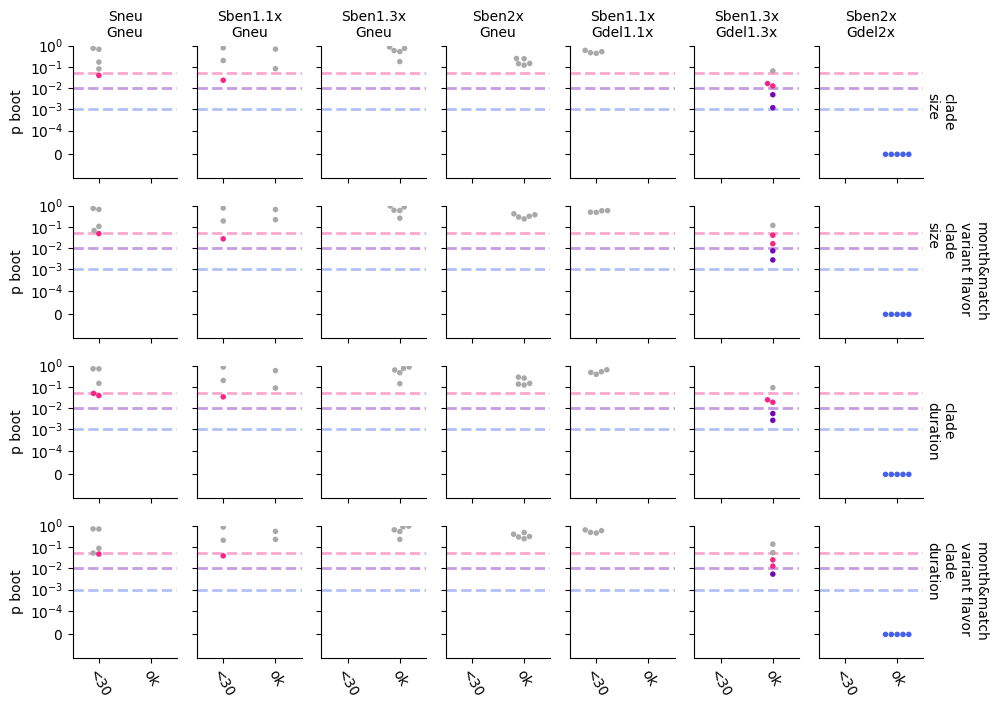

teeplots/2025-05-19-compscreen-multistrain-summary/col=trt-name+comparator=month+hue=sig+kind=swarm+row=y+viz=catplot+x=smallsamp+y=p-binom+ext=.pdf
teeplots/2025-05-19-compscreen-multistrain-summary/col=trt-name+comparator=month+hue=sig+kind=swarm+row=y+viz=catplot+x=smallsamp+y=p-binom+ext=.png


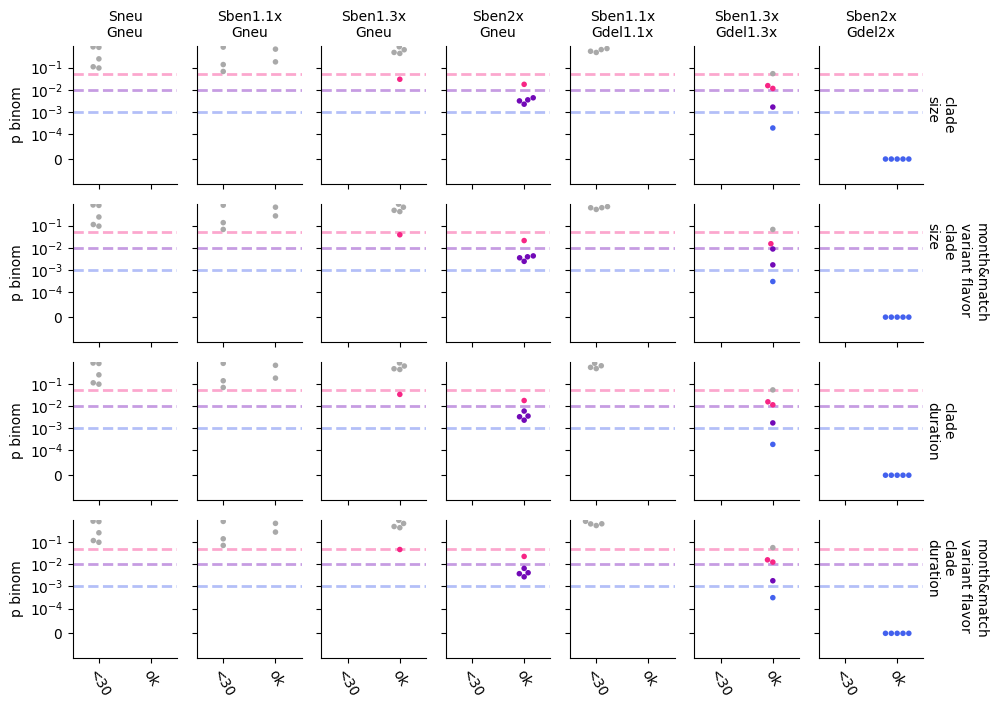

teeplots/2025-05-19-compscreen-multistrain-summary/col=trt-name+comparator=month+hue=sig+kind=swarm+row=y+viz=catplot+x=smallsamp+y=p-mw+ext=.pdf
teeplots/2025-05-19-compscreen-multistrain-summary/col=trt-name+comparator=month+hue=sig+kind=swarm+row=y+viz=catplot+x=smallsamp+y=p-mw+ext=.png


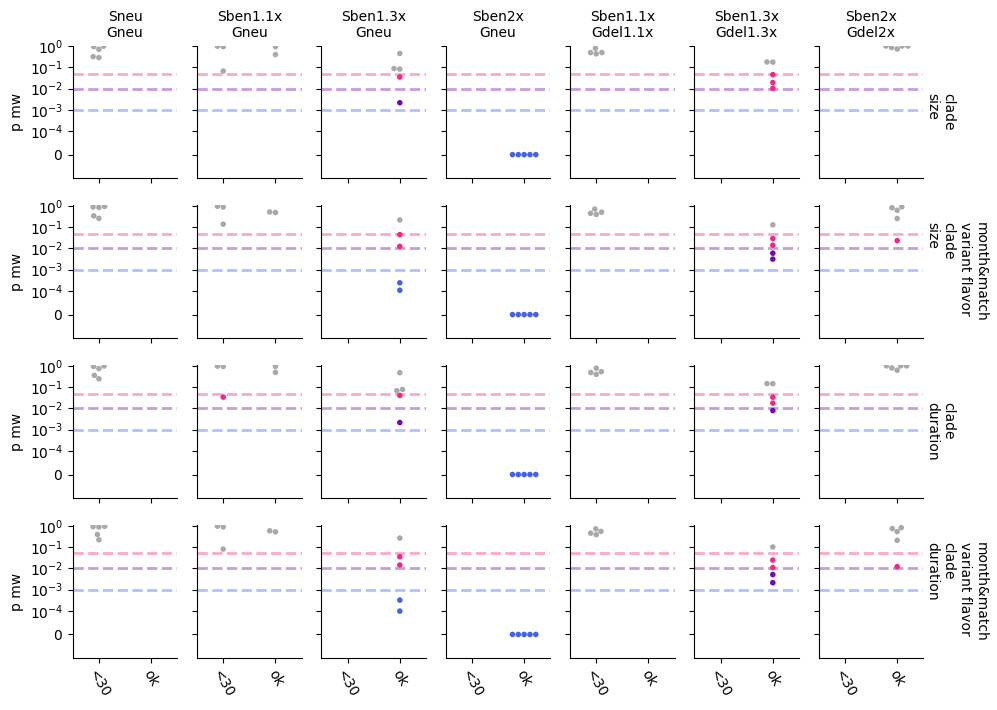

In [11]:
bins = [-np.inf, 0.001, 0.01, 0.05, np.inf]
labels = ["<0.001", "<0.01", "<0.05", "ns"]
gentle_palette = ["#4361EE", "#7209B7", "#F72585", "#A9A9A9"]

for y in "p_boot", "p_binom", "p_mw":
    display(HTML(f"<h1>{y=}</h1>"))

    data = results_df[
        (results_df["trt_hsurf_bits"] == 0)
        & (
            results_df["trt_n_downsample"]
            == results_df["trt_n_downsample"].max()
        )
        & (results_df["label"] != "all")
    ].copy()
    data["sig"] = pd.cut(
        data[y],
        bins=bins,
        labels=labels,
        include_lowest=True,
    )
    data["sig"] = data["sig"].cat.set_categories(labels, ordered=True)
    data["smallsamp"] = data["n_grp"] < 30
    data["smallsamp"] = data["smallsamp"].map({True: "<30", False: "ok"})
    data["y_"] = (
        data["y"]
        .str.replace("month\n", "")
        .str.replace("num leaves", "clade\nsize")
        .str.replace("clade duration", "clade\nduration")
        .str.replace(":", "\n")
    )
    col_order = filter(
        set(data["trt_name_"]).__contains__,
        [
            "Sneu\nGneu",
            "Sben1.1x\nGneu",
            "Sben1.3x\nGneu",
            "Sben2x\nGneu",
            "Sben1.1x\nGdel1.1x",
            "Sben1.3x\nGdel1.3x",
            "Sben2x\nGdel2x",
        ],
    )
    col_order = [*col_order]
    with tp.teed(
        sns.catplot,
        data=data[
            data["y"].str.startswith("month").values
            & (data["label"] == "focal")
        ],
        y=y,
        col="trt_name_",
        row="y_",
        hue="sig",
        x="smallsamp",
        col_order=col_order,
        legend=False,
        kind="swarm",
        margin_titles=True,
        height=1.8,
        aspect=0.8,
        size=4,
        palette=gentle_palette,
        teeplot_outattrs={"comparator": "month"},
        teeplot_subdir=teeplot_subdir,
    ) as teed:

        teed.set_titles(col_template="{col_name}", row_template="{row_name}")
        for ax in teed.axes.flat:
            ax.set_yscale("symlog", linthresh=0.0001)
            ax.set_ylim(-0.0001, None)
            ax.axhline(
                0.05,
                alpha=0.4,
                color=gentle_palette[2],
                linestyle="--",
                linewidth=2,
            )
            ax.axhline(
                0.01,
                alpha=0.4,
                color=gentle_palette[1],
                linestyle="--",
                linewidth=2,
            )
            ax.axhline(
                0.001,
                alpha=0.4,
                color=gentle_palette[0],
                linestyle="--",
                linewidth=2,
            )
            ax.tick_params(axis="x", rotation=-60)
            ax.set_xlabel("")
            ax.set_ylabel(y.replace("_", " "))

        teed.tight_layout()


teeplots/2025-05-19-compscreen-multistrain-summary/col=trt-name+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=p-boot+ext=.pdf
teeplots/2025-05-19-compscreen-multistrain-summary/col=trt-name+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=p-boot+ext=.png


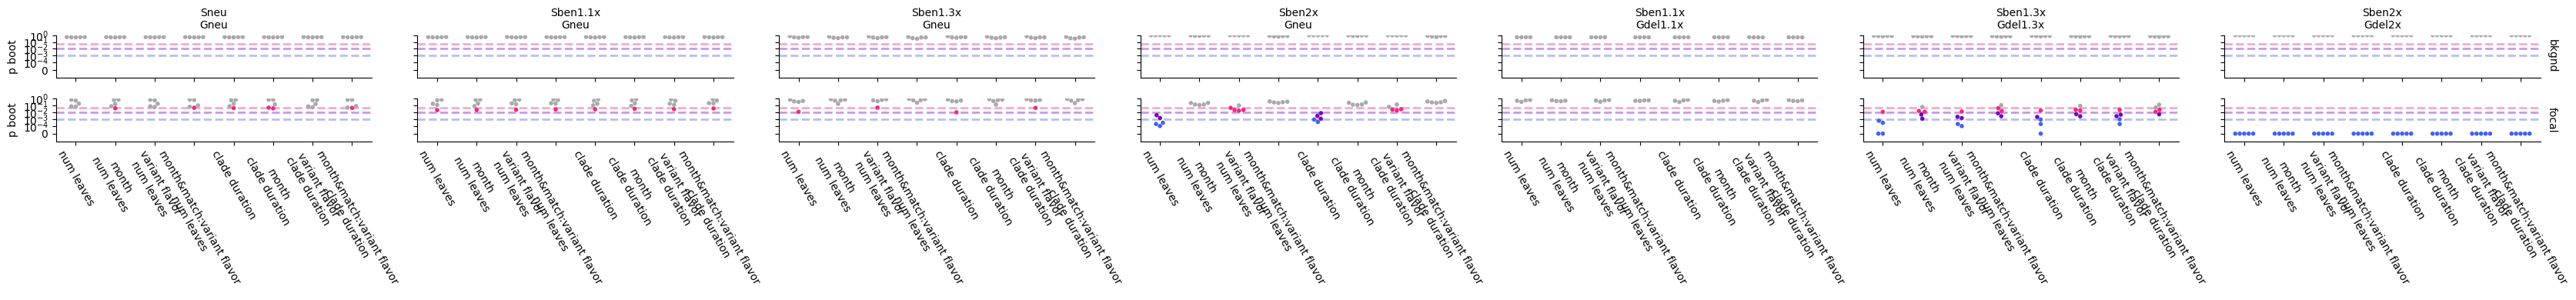

teeplots/2025-05-19-compscreen-multistrain-summary/col=trt-name+comparator=month+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=p-boot+ext=.pdf
teeplots/2025-05-19-compscreen-multistrain-summary/col=trt-name+comparator=month+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=p-boot+ext=.png


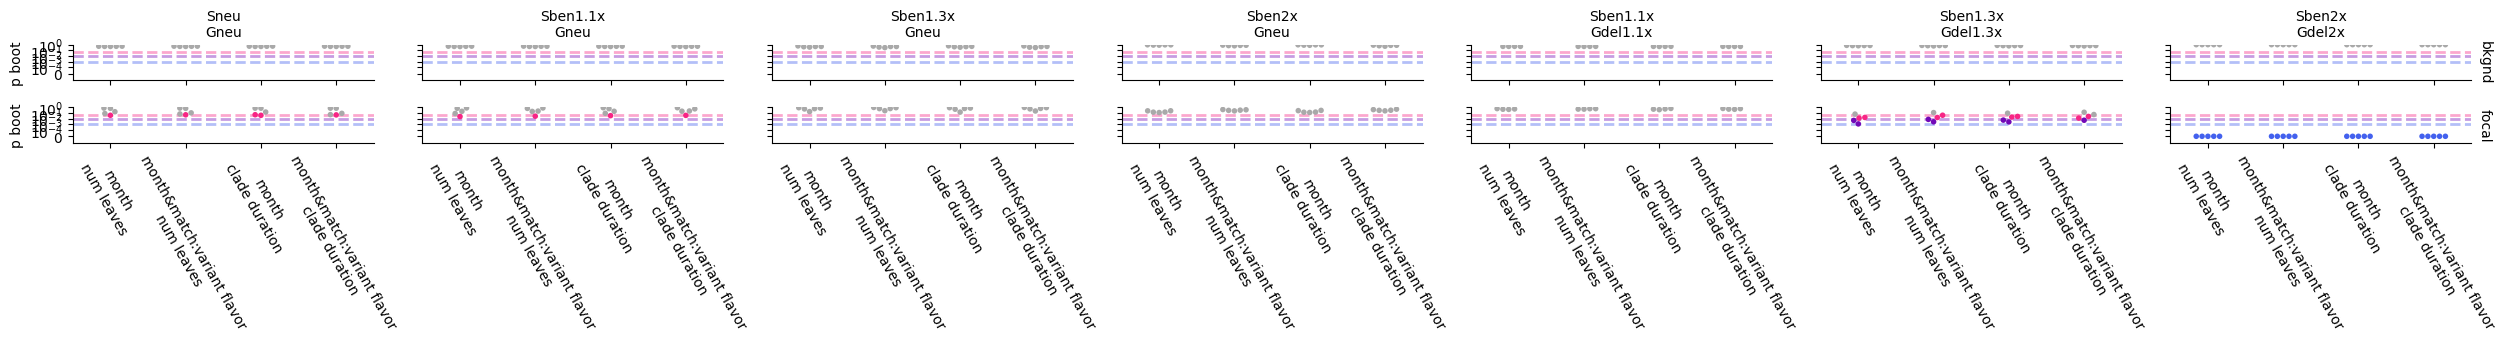

teeplots/2025-05-19-compscreen-multistrain-summary/col=trt-name+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=p-binom+ext=.pdf
teeplots/2025-05-19-compscreen-multistrain-summary/col=trt-name+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=p-binom+ext=.png


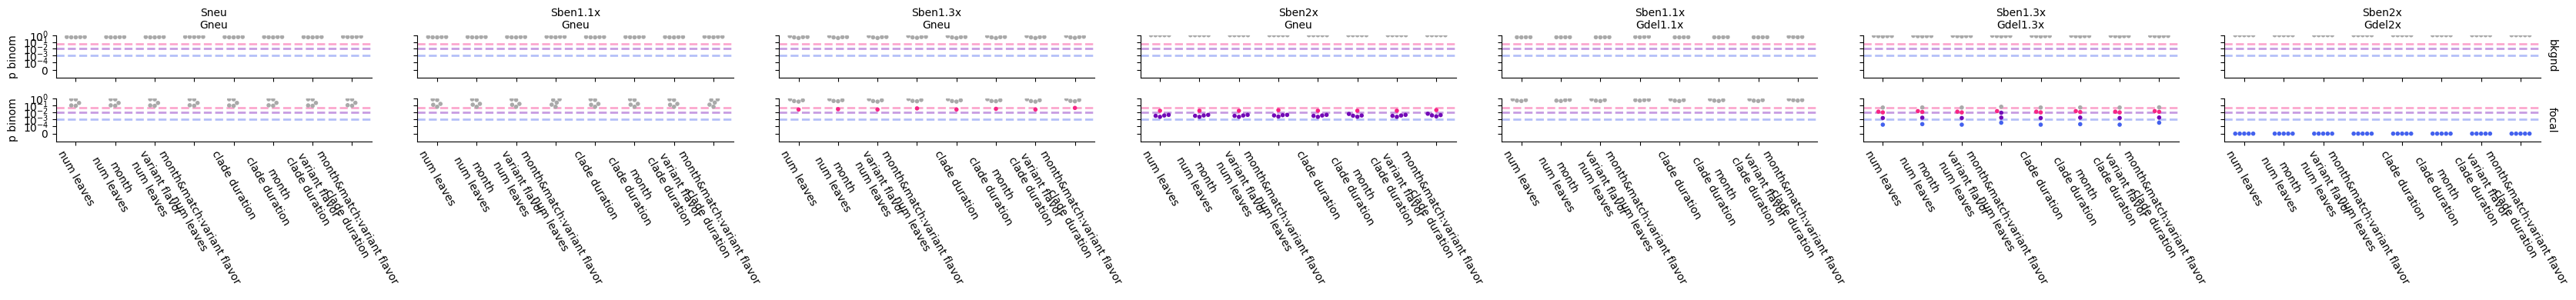

teeplots/2025-05-19-compscreen-multistrain-summary/col=trt-name+comparator=month+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=p-binom+ext=.pdf
teeplots/2025-05-19-compscreen-multistrain-summary/col=trt-name+comparator=month+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=p-binom+ext=.png


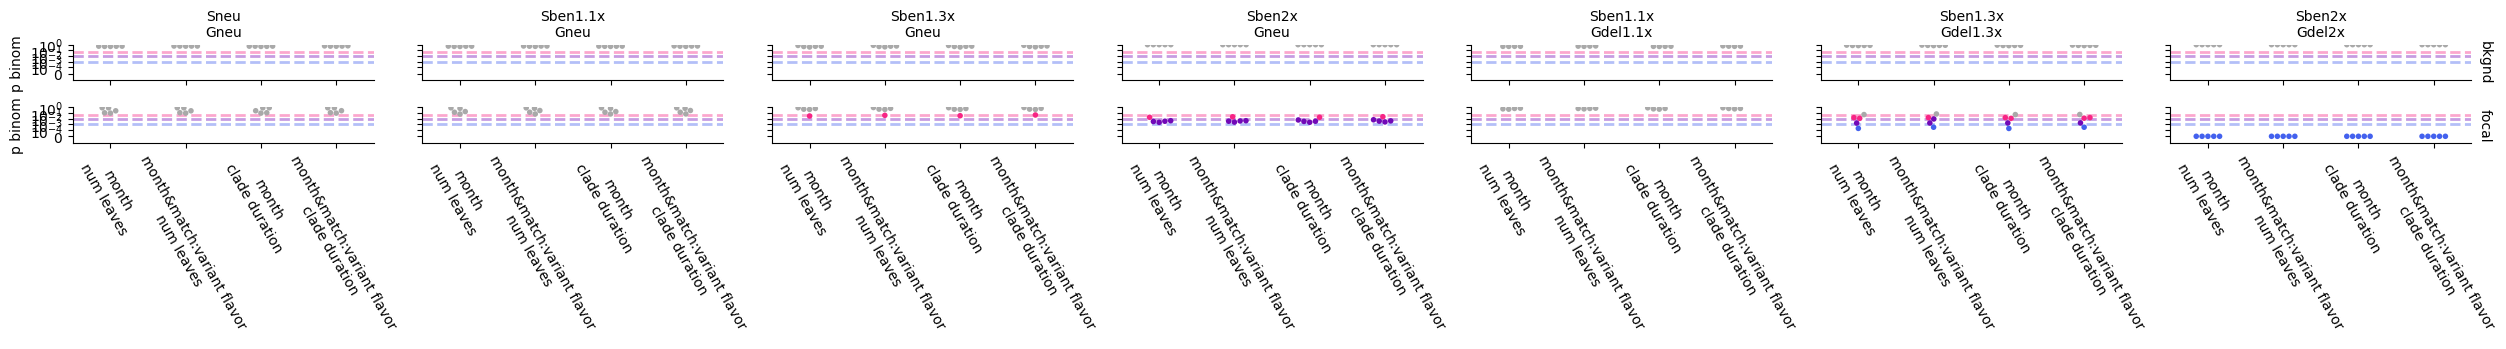

teeplots/2025-05-19-compscreen-multistrain-summary/col=trt-name+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=p-mw+ext=.pdf
teeplots/2025-05-19-compscreen-multistrain-summary/col=trt-name+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=p-mw+ext=.png


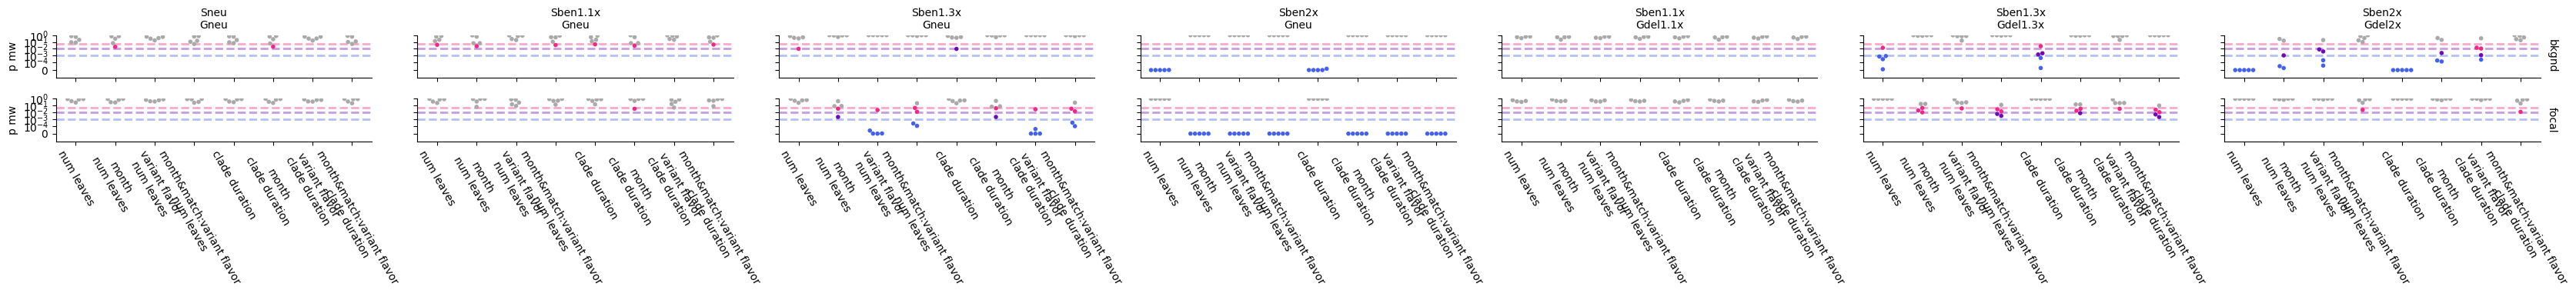

teeplots/2025-05-19-compscreen-multistrain-summary/col=trt-name+comparator=month+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=p-mw+ext=.pdf
teeplots/2025-05-19-compscreen-multistrain-summary/col=trt-name+comparator=month+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=p-mw+ext=.png


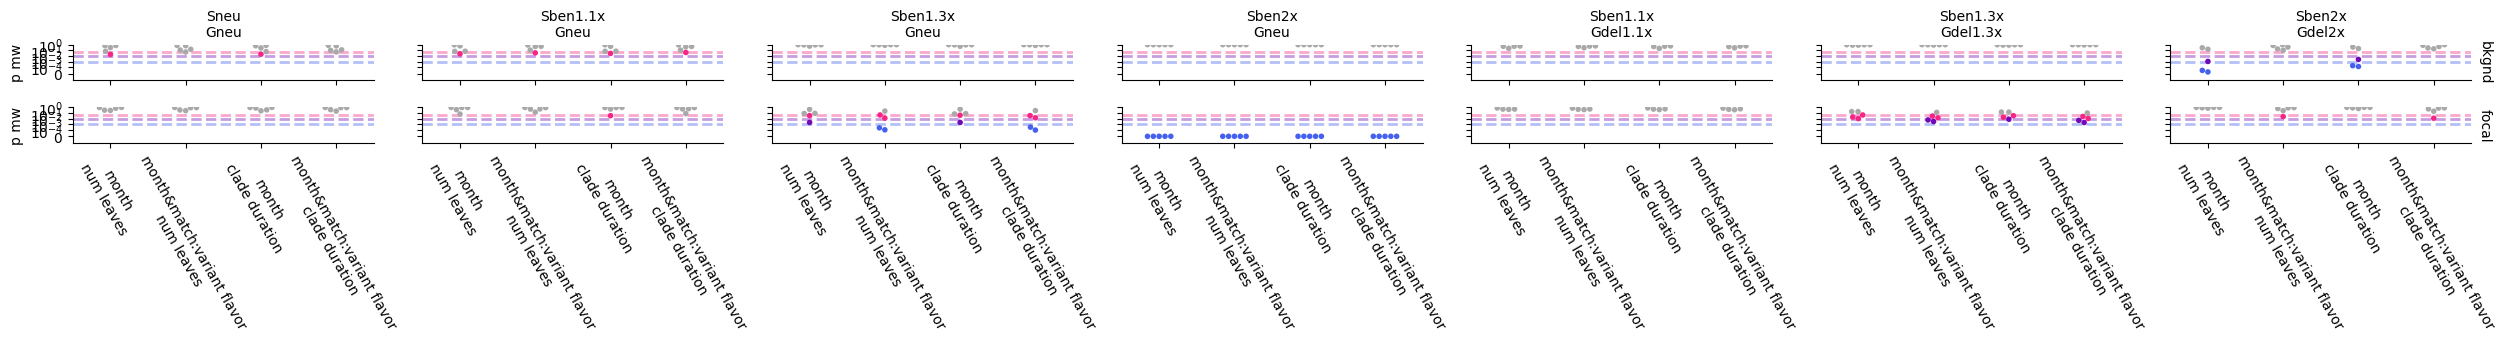

teeplots/2025-05-19-compscreen-multistrain-summary/col=trt-name+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=u-mw+ext=.pdf
teeplots/2025-05-19-compscreen-multistrain-summary/col=trt-name+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=u-mw+ext=.png


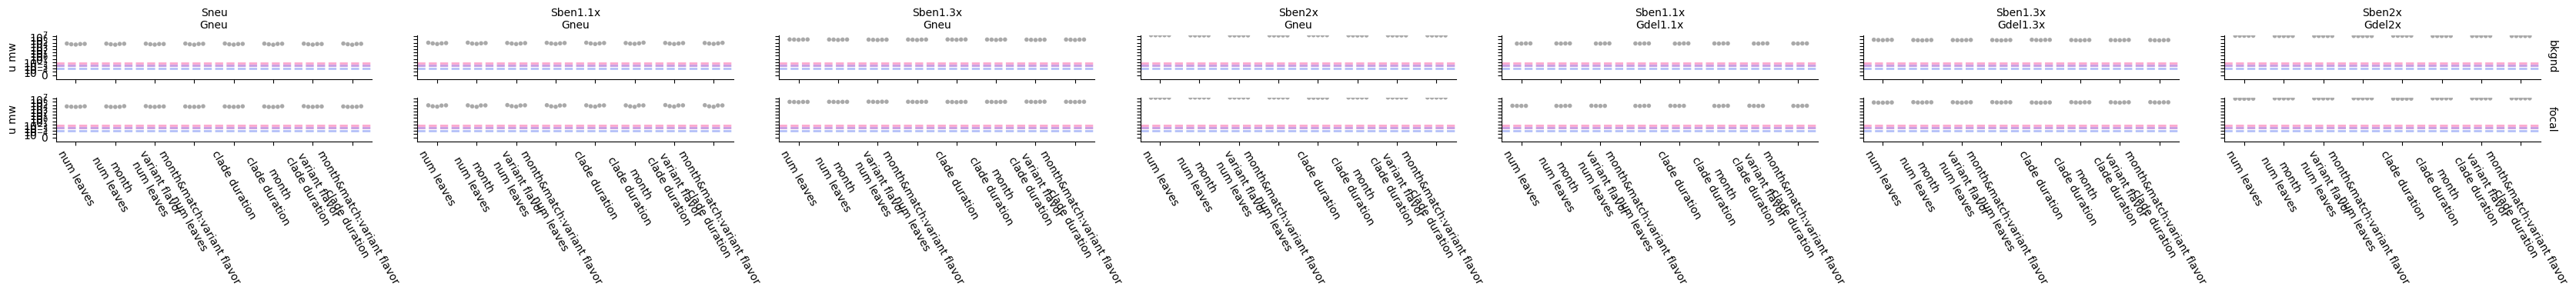

teeplots/2025-05-19-compscreen-multistrain-summary/col=trt-name+comparator=month+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=u-mw+ext=.pdf
teeplots/2025-05-19-compscreen-multistrain-summary/col=trt-name+comparator=month+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=u-mw+ext=.png


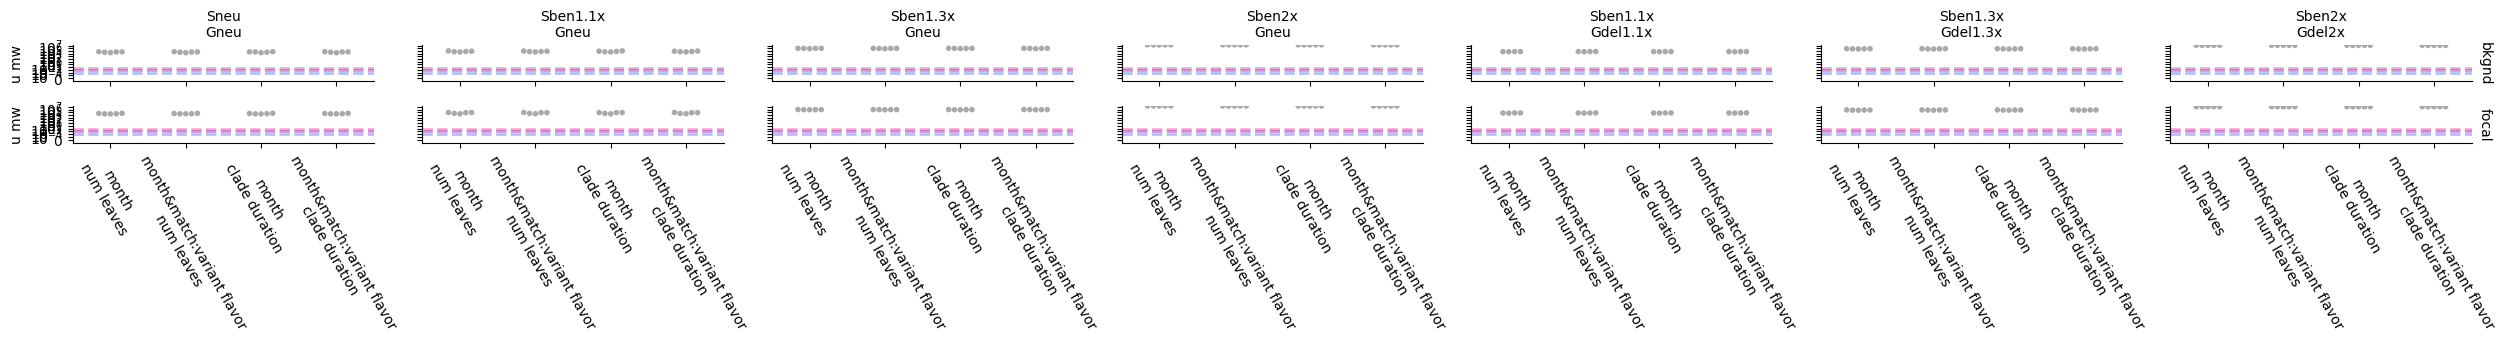

teeplots/2025-05-19-compscreen-multistrain-summary/col=trt-name+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=cliffs-delta+ext=.pdf
teeplots/2025-05-19-compscreen-multistrain-summary/col=trt-name+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=cliffs-delta+ext=.png


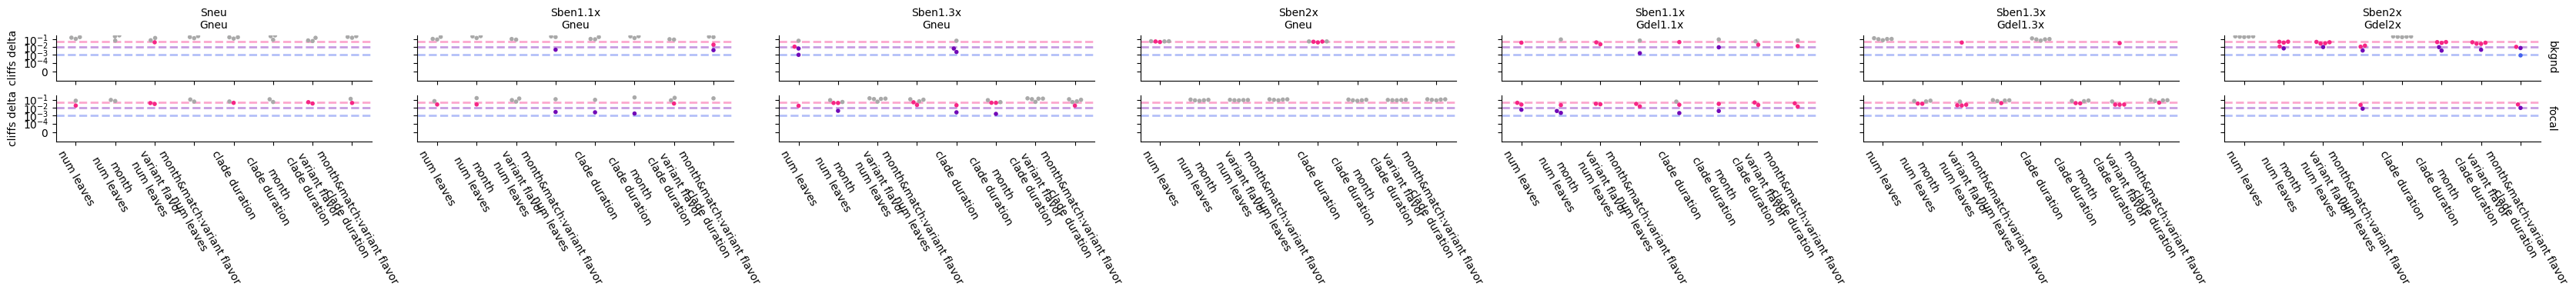

teeplots/2025-05-19-compscreen-multistrain-summary/col=trt-name+comparator=month+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=cliffs-delta+ext=.pdf
teeplots/2025-05-19-compscreen-multistrain-summary/col=trt-name+comparator=month+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=cliffs-delta+ext=.png


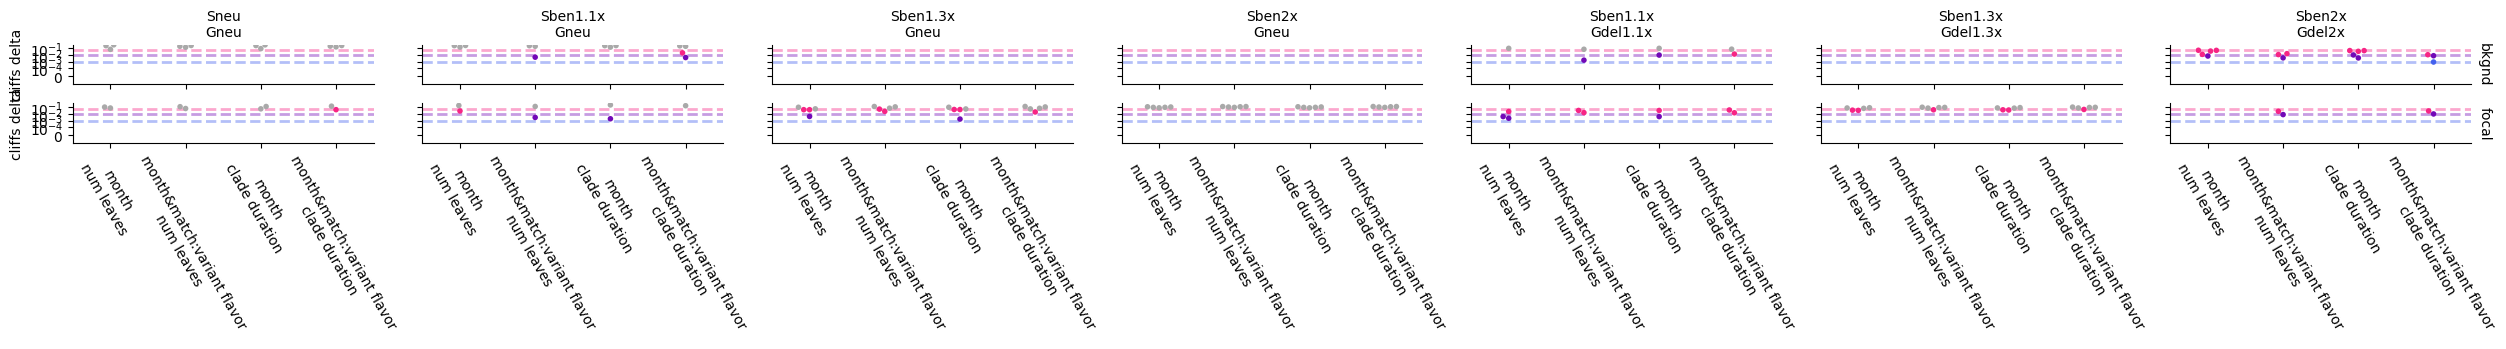

In [12]:
bins = [-np.inf, 0.001, 0.01, 0.05, np.inf]
labels = ["<0.001", "<0.01", "<0.05", "ns"]
gentle_palette = ["#4361EE", "#7209B7", "#F72585", "#A9A9A9"]

for y in "p_boot", "p_binom", "p_mw", "u_mw", "cliffs_delta":
    display(HTML(f"<h1>{y=}</h1>"))

    data = results_df[
        (results_df["trt_hsurf_bits"] == 0)
        & (
            results_df["trt_n_downsample"]
            == results_df["trt_n_downsample"].max()
        )
        & (results_df["label"] != "all")
    ].copy()
    data["sig"] = pd.cut(
        data[y],
        bins=bins,
        labels=labels,
        include_lowest=True,
    )
    data["sig"] = data["sig"].cat.set_categories(labels, ordered=True)
    col_order = filter(
        set(data["trt_name_"]).__contains__,
        [
            "Sneu\nGneu",
            "Sben1.1x\nGneu",
            "Sben1.3x\nGneu",
            "Sben2x\nGneu",
            "Sben1.1x\nGdel1.1x",
            "Sben1.3x\nGdel1.3x",
            "Sben2x\nGdel2x",
        ],
    )
    col_order = [*col_order]
    with tp.teed(
        sns.catplot,
        data=data,
        y=y,
        x="y",
        col="trt_name_",
        row="label",
        hue="sig",
        col_order=col_order,
        legend=False,
        kind="swarm",
        margin_titles=True,
        height=2,
        aspect=2.4,
        size=4,
        palette=gentle_palette,
        teeplot_subdir=teeplot_subdir,
    ) as teed:
        teed.set_titles(col_template="{col_name}", row_template="{row_name}")
        for ax in teed.axes.flat:
            ax.set_yscale("symlog", linthresh=0.0001)
            ax.set_ylim(-0.0001, None)
            ax.axhline(
                0.05,
                alpha=0.4,
                color=gentle_palette[2],
                linestyle="--",
                linewidth=2,
            )
            ax.axhline(
                0.01,
                alpha=0.4,
                color=gentle_palette[1],
                linestyle="--",
                linewidth=2,
            )
            ax.axhline(
                0.001,
                alpha=0.4,
                color=gentle_palette[0],
                linestyle="--",
                linewidth=2,
            )
            ax.tick_params(axis="x", rotation=-60)
            ax.set_xlabel("")
            ax.set_ylabel(y.replace("_", " "))

        teed.tight_layout()

    with tp.teed(
        sns.catplot,
        data=data[data["y"].str.startswith("month").values],
        y=y,
        x="y",
        col="trt_name_",
        row="label",
        hue="sig",
        col_order=col_order,
        legend=False,
        kind="swarm",
        margin_titles=True,
        height=1.8,
        aspect=2,
        size=4,
        palette=gentle_palette,
        teeplot_outattrs={"comparator": "month"},
        teeplot_subdir=teeplot_subdir,
    ) as teed:
        teed.set_titles(col_template="{col_name}", row_template="{row_name}")
        for ax in teed.axes.flat:
            ax.set_yscale("symlog", linthresh=0.0001)
            ax.set_ylim(-0.0001, None)
            ax.axhline(
                0.05,
                alpha=0.4,
                color=gentle_palette[2],
                linestyle="--",
                linewidth=2,
            )
            ax.axhline(
                0.01,
                alpha=0.4,
                color=gentle_palette[1],
                linestyle="--",
                linewidth=2,
            )
            ax.axhline(
                0.001,
                alpha=0.4,
                color=gentle_palette[0],
                linestyle="--",
                linewidth=2,
            )
            ax.tick_params(axis="x", rotation=-60)
            ax.set_xlabel("")
            ax.set_ylabel(y.replace("_", " "))

        teed.tight_layout()
